In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [7]:
df = pd.read_csv('possum.csv')
df

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,tail,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [8]:
df.shape

(104, 14)

In [9]:
print('The dataset has {} rows and {} columns'.format(df.shape[0], df.shape[1]))

The dataset has 104 rows and 14 columns


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   tail      104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


In [11]:
df.isna().sum()

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
tail        0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

In [12]:
df.dropna(inplace=True)
df.shape

(101, 14)

In [13]:
print(df.duplicated().sum())

0


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
case,101.0,52.762376,30.573894,1.0,26.0,54.0,79.0,104.0
site,101.0,3.673267,2.366892,1.0,1.0,4.0,6.0,7.0
age,101.0,3.821782,1.915182,1.0,2.0,3.0,5.0,9.0
hdlngth,101.0,92.730693,3.518714,82.5,90.7,92.9,94.8,103.1
skullw,101.0,56.960396,3.102679,50.0,55.0,56.4,58.1,68.6
totlngth,101.0,87.269307,4.196802,75.0,84.5,88.0,90.0,96.5
tail,101.0,37.049505,1.971681,32.0,36.0,37.0,38.0,43.0
footlgth,101.0,68.398020,4.413502,60.3,64.5,67.9,72.5,77.9
earconch,101.0,48.133663,4.060352,41.3,44.8,46.8,52.0,56.2
eye,101.0,15.050495,1.058643,12.8,14.4,14.9,15.7,17.8


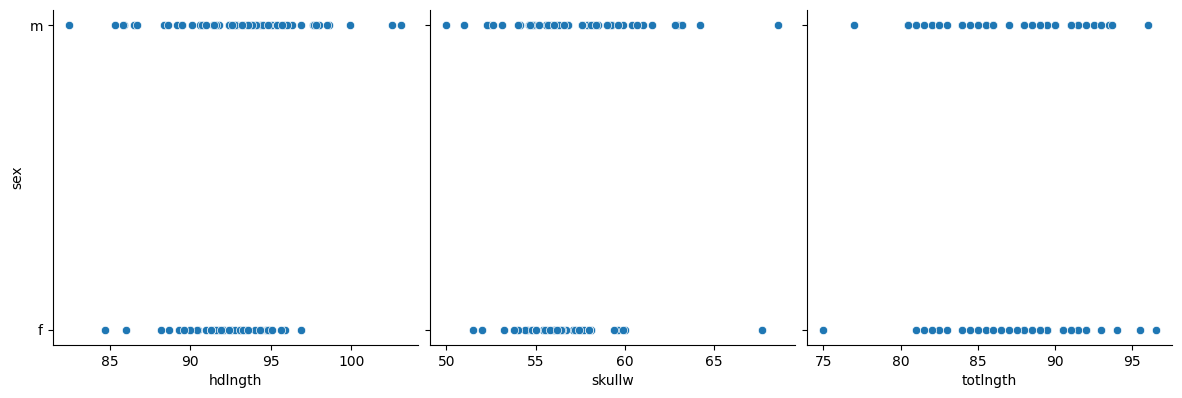

In [15]:
sns.pairplot(df, x_vars=['hdlngth', 'skullw', 'totlngth'], y_vars=['sex'], kind='scatter', height=4)

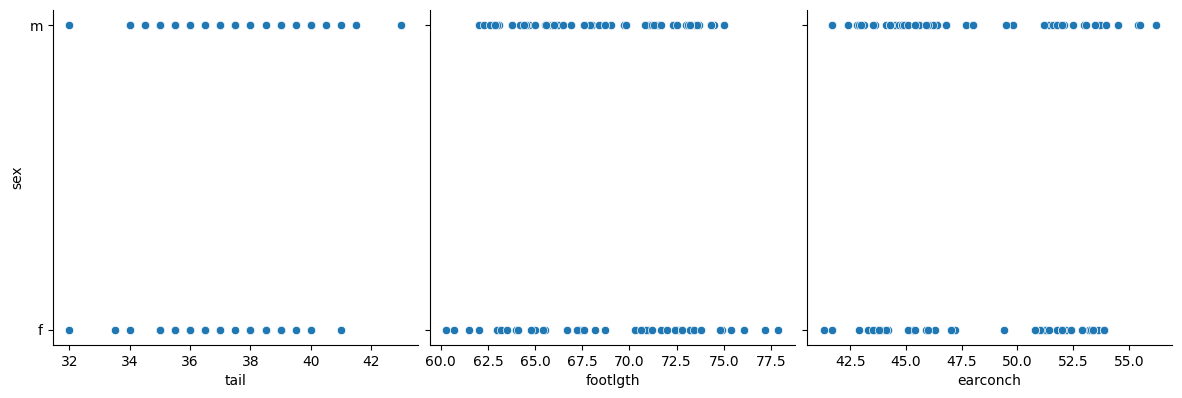

In [16]:
sns.pairplot(df, x_vars=['tail', 'footlgth', 'earconch'], y_vars=['sex'], kind='scatter', height=4)

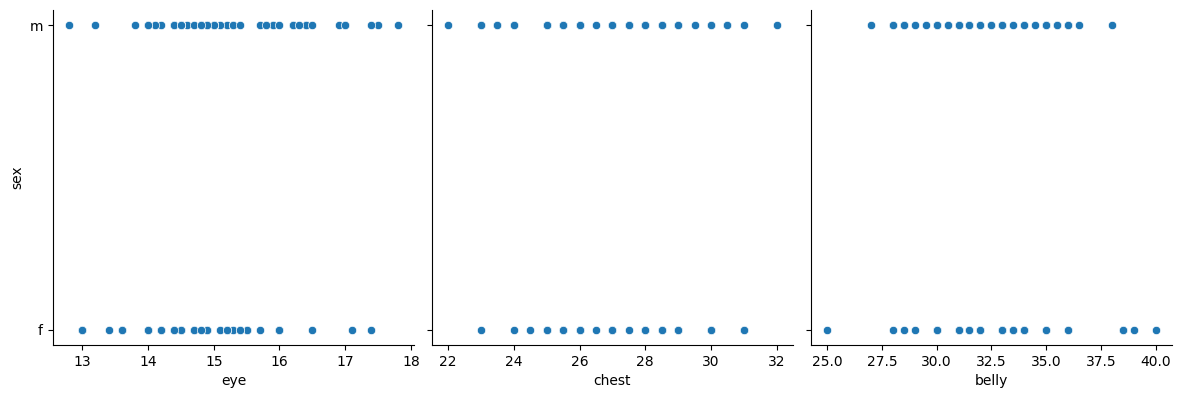

In [21]:
sns.pairplot(df, x_vars=['eye', 'chest', 'belly'], y_vars=['sex'], kind='scatter', height=4)

In [17]:
# Check for outliers

In [54]:
import plotly.express as px

px.box(df, x=['footlgth','tail','earconch'])

In [53]:
px.box(df, x=['hdlngth', 'skullw', 'totlngth'])

In [84]:
px.box(df, x=['eye', 'chest', 'belly'])

In [51]:
df[(df['skullw']<51) | (df['skullw']>62.8)]

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,tail,footlgth,earconch,eye,chest,belly
16,17,1,Vic,f,1.0,94.7,67.7,89.5,36.5,73.2,53.2,14.7,29.0,31.0
47,48,3,other,m,5.0,98.6,63.2,85.0,34.0,66.9,44.9,17.0,28.0,35.0
53,54,4,other,m,7.0,96.9,63.0,91.5,43.0,71.3,46.0,17.5,30.0,36.5
54,55,4,other,m,2.0,103.1,63.2,92.5,38.0,72.5,44.9,16.4,30.5,36.0
57,58,4,other,m,3.0,94.5,64.2,91.0,39.0,66.5,46.4,14.4,30.5,33.0
78,79,6,other,m,1.0,85.8,50.0,81.0,36.5,62.8,43.0,14.8,22.0,28.5
97,98,7,other,m,5.0,93.2,68.6,84.0,35.0,65.6,44.3,14.5,28.5,32.0


In [76]:
df[(df['belly']<27) | (df['belly']>38.5)]

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,tail,footlgth,earconch,eye,chest,belly
20,21,1,Vic,f,3.0,95.9,58.1,96.5,39.5,77.9,52.9,14.2,30.0,40.0
38,39,2,Vic,f,1.0,84.7,51.5,75.0,34.0,68.7,53.4,13.0,25.0,25.0
56,57,4,other,f,4.0,95.1,59.4,93.0,41.0,67.2,45.3,14.5,31.0,39.0


In [ ]:
df[(df['chest']<20) | (df['chest']>30.5)]

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,tail,footlgth,earconch,eye,chest,belly
10,11,1,Vic,f,9.0,93.3,57.2,89.5,39.0,77.2,51.3,14.9,31.0,34.0
24,25,1,Vic,m,3.0,95.8,58.5,91.5,35.5,72.3,51.6,14.9,31.0,35.0
58,59,4,other,m,2.0,102.5,62.8,96.0,40.0,73.2,44.5,14.7,32.0,36.0


In [ ]:
df.drop(df[(df['chest']<20) | (df['chest']>30.5)].index,inplace=True)
df.shape

(88, 14)

In [77]:
df.drop(df[(df['belly']<27) | (df['belly']>38.5)].index,inplace=True)

In [52]:
df.drop(df[(df['skullw']<51) | (df['skullw']>62.8)].index, inplace=True)
df.shape

(94, 14)

<Axes: >

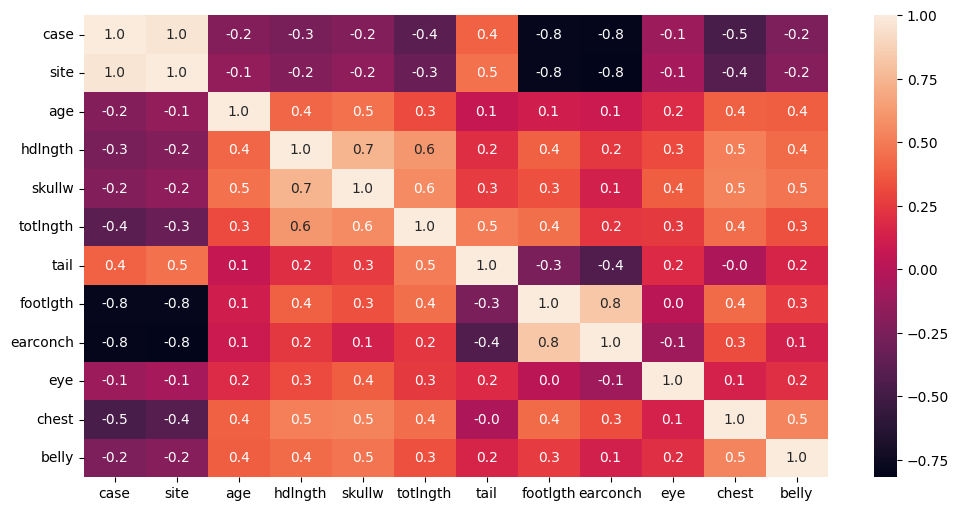

In [85]:
plt.figure(figsize=(12, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt = '0.01f')

In [57]:
X = df.drop(['case','site','Pop','sex'],axis=1)
y = df.sex

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [65]:
# Decision Tree Classifier

In [59]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
print('Training Score: ', clf.score(X_train, y_train))
print('Testing Score: ', clf.score(X_test, y_test))

Training Score:  1.0
Testing Score:  0.6551724137931034


In [60]:
# Random Forest 

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
param = {
    'n_estimators' : range(2,20),
    'criterion' : ['gini', 'entropy']
}
rf = RandomForestClassifier()
grid = GridSearchCV(estimator=rf, param_grid = param)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'n_estimators': 13}
0.5959064327485379


In [64]:
rclf = RandomForestClassifier(n_estimators=3, criterion='gini')
rclf.fit(X_train, y_train)
print('Training Score: ', rclf.score(X_train, y_train))
print('Testing Score: ', rclf.score(X_test, y_test))

Training Score:  0.9230769230769231
Testing Score:  0.5517241379310345


In [66]:
#Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
print('Training Score: ', model.score(X_train, y_train))
print('Testing Score: ', model.score(X_test, y_test))

Training Score:  0.7076923076923077
Testing Score:  0.6896551724137931


In [67]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
train_scores = []
test_scores = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    sc = knn.score(X_test, y_test)
    train_scores.append(knn.score(X_train, y_train))
    sc = knn.score(X_test, y_test)
    test_scores.append(sc)
print(train_scores)
print(test_scores)

[1.0, 0.8461538461538461, 0.8153846153846154, 0.7230769230769231, 0.7384615384615385, 0.6923076923076923, 0.6461538461538462, 0.6923076923076923, 0.6923076923076923, 0.6461538461538462, 0.6615384615384615, 0.5692307692307692, 0.5846153846153846, 0.6153846153846154, 0.6, 0.5846153846153846, 0.6307692307692307, 0.6461538461538462, 0.6307692307692307, 0.6153846153846154]
[0.5172413793103449, 0.41379310344827586, 0.5517241379310345, 0.5517241379310345, 0.5862068965517241, 0.4482758620689655, 0.5172413793103449, 0.3793103448275862, 0.4482758620689655, 0.3793103448275862, 0.4827586206896552, 0.3103448275862069, 0.3793103448275862, 0.3793103448275862, 0.4482758620689655, 0.3793103448275862, 0.4482758620689655, 0.3103448275862069, 0.5517241379310345, 0.3103448275862069]


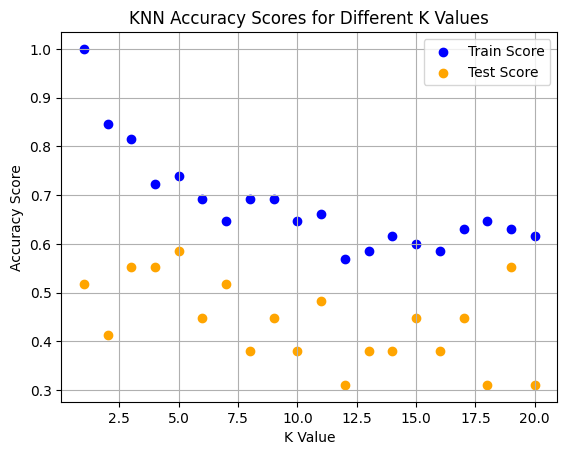

In [69]:
plt.scatter(range(1, 21), train_scores, marker='o', color='blue', label='Train Score')
plt.scatter(range(1, 21), test_scores, marker='o', color='orange', label='Test Score')
plt.xlabel('K Value')
plt.ylabel('Accuracy Score')
plt.title('KNN Accuracy Scores for Different K Values')
plt.legend()
plt.grid()
plt.show()

In [70]:
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train, y_train)
print('Training Score: ', knn.score(X_train, y_train))
print('Test Score: ', knn.score(X_test, y_test))

Training Score:  0.6615384615384615
Test Score:  0.4827586206896552


In [71]:
#SVM

In [72]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)
print('Training Score: ', model.score(X_train, y_train))    
print('Testing Score: ', model.score(X_test, y_test))

Training Score:  0.7230769230769231
Testing Score:  0.6206896551724138


In [73]:
model = SVC(kernel='poly')
model.fit(X_train, y_train)
print('Training Score: ', model.score(X_train, y_train))    
print('Testing Score: ', model.score(X_test, y_test))

Training Score:  0.6461538461538462
Testing Score:  0.6551724137931034


In [75]:
#Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)
print('Training Score: ', model.score(X_train, y_train))
print('Testing Score: ', model.score(X_test, y_test))

Training Score:  0.6615384615384615
Testing Score:  0.5862068965517241
